In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "drive/My Drive/Turning_human_labels.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

In [3]:
df.describe()

,Turn ID,Participant ID number,number_of_turning_steps,turning_duration
count,1749.000000,1749.000000,1749.00000,1749.000000
mean,1918.228702,547.038879,2.57976,1.913022
std,1096.864601,219.811623,1.37444,0.804711
min,0.000000,204.000000,1.00000,1.038000
25%,1057.000000,396.000000,2.00000,1.419000
50%,2023.000000,495.000000,2.00000,1.742999
75%,2793.000000,744.000000,3.00000,2.143000
max,3744.000000,971.000000,18.00000,9.380000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1749 entries, 0 to 1748
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Turn ID                  1749 non-null   int64  
 1   Participant ID number    1749 non-null   int64  
 2   PD_or_C                  1749 non-null   object 
 3   number_of_turning_steps  1749 non-null   int64  
 4   turning_angle            1749 non-null   object 
 5   type_of_turn             1749 non-null   object 
 6   turning_duration         1749 non-null   float64
 7   On_or_Off_medication     1749 non-null   object 
 8   DBS_state                1749 non-null   object 
 9   clinical_assessment      1749 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 136.8+ KB


In [5]:
df = df[df["type_of_turn"] != "-"]
df.drop(["clinical_assessment"], axis=1, inplace=True)
df.drop(["DBS_state"], axis=1, inplace=True)

<ipython-input-5-a29bf36ec2bd>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(["clinical_assessment"], axis=1, inplace=True)
<ipython-input-5-a29bf36ec2bd>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(["DBS_state"], axis=1, inplace=True)


In [6]:
df['turning_angle'] = df['turning_angle'].str.replace('_degrees', '').astype(float)

# Check for missing values
missing_values = df.isnull().sum()
display(missing_values)

,0
Turn ID,0
Participant ID number,0
PD_or_C,0
number_of_turning_steps,0
turning_angle,0
type_of_turn,0
turning_duration,0
On_or_Off_medication,0


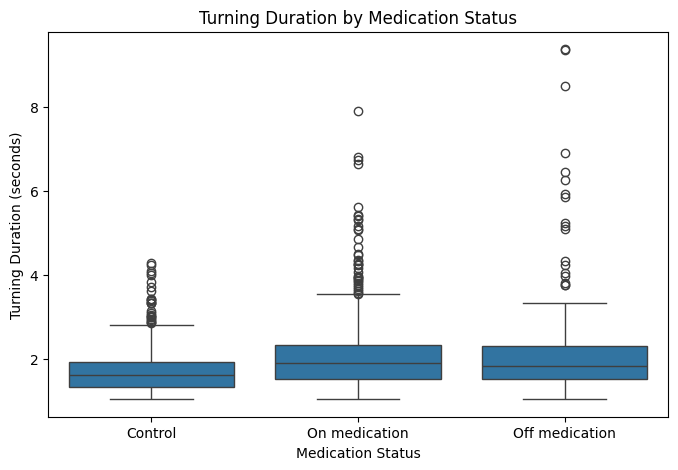

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="On_or_Off_medication", y="turning_duration", data=df)
plt.title("Turning Duration by Medication Status")
plt.xlabel("Medication Status")
plt.ylabel("Turning Duration (seconds)")
plt.show()

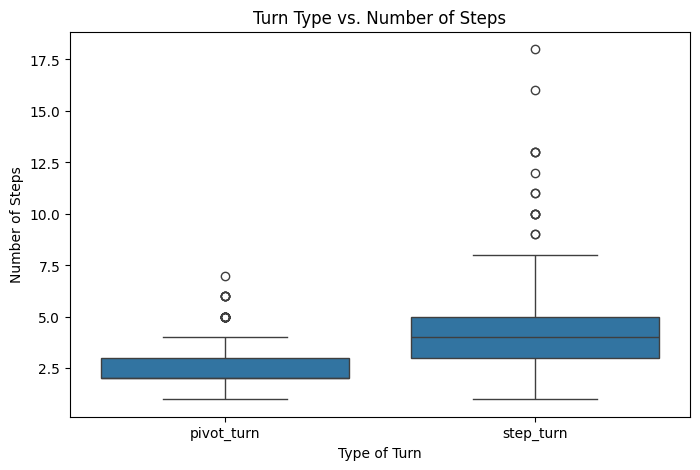

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="type_of_turn", y="number_of_turning_steps", data=df)
plt.title("Turn Type vs. Number of Steps")
plt.xlabel("Type of Turn")
plt.ylabel("Number of Steps")
plt.show()

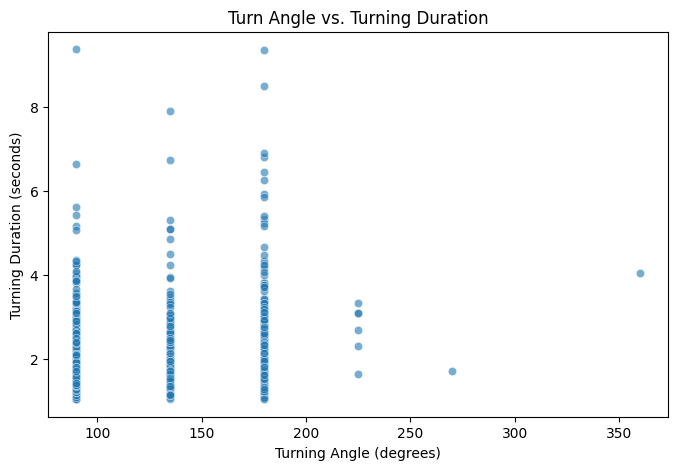

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="turning_angle", y="turning_duration", data=df, alpha=0.6)
plt.title("Turn Angle vs. Turning Duration")
plt.xlabel("Turning Angle (degrees)")
plt.ylabel("Turning Duration (seconds)")
plt.show()

In [7]:
non_numeric_cols = df.select_dtypes(include=['object']).columns
display(f"Non-numeric columns: {list(non_numeric_cols)}")
df_encoded = df.copy()
for col in non_numeric_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

"Non-numeric columns: ['PD_or_C', 'type_of_turn', 'On_or_Off_medication']"

In [8]:
df.head()

,Turn ID,Participant ID number,PD_or_C,number_of_turning_steps,turning_angle,type_of_turn,turning_duration,On_or_Off_medication
0,0,230,C,4,90.0,pivot_turn,1.980999,Control
1,2,230,C,2,90.0,pivot_turn,1.278000,Control
2,4,230,C,2,90.0,pivot_turn,1.092999,Control
3,5,230,C,2,90.0,pivot_turn,1.205999,Control
4,7,230,C,2,90.0,pivot_turn,1.399000,Control


In [ ]:
for col in non_numeric_cols:
    print(f"Original: {col} - Unique values: {df[col].unique()}")
    print(f"Encoded: {col} - Unique values: {df_encoded[col].unique()}\n")

Original: PD_or_C - Unique values: ['C' 'PD']
Encoded: PD_or_C - Unique values: [0 1]

Original: type_of_turn - Unique values: ['pivot_turn' 'step_turn']
Encoded: type_of_turn - Unique values: [0 1]

Original: On_or_Off_medication - Unique values: ['Control' 'On medication' 'Off medication']
Encoded: On_or_Off_medication - Unique values: [0 2 1]



In [ ]:
print(df_encoded.dtypes)

Turn ID                      int64
Participant ID number        int64
PD_or_C                       int8
number_of_turning_steps      int64
turning_angle              float64
type_of_turn                  int8
turning_duration           float64
On_or_Off_medication          int8
dtype: object


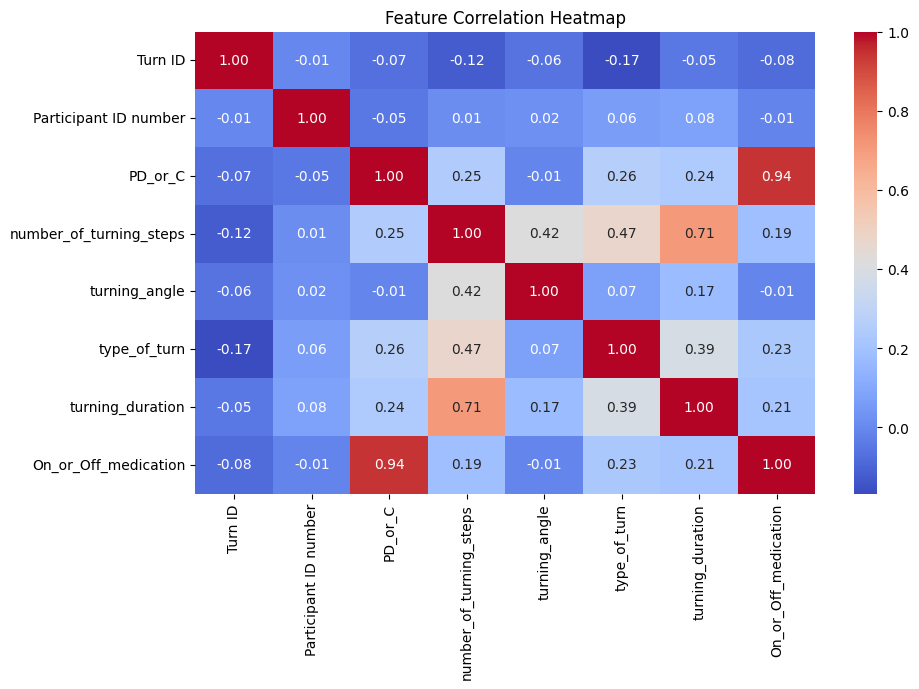

In [ ]:
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

- PD/C vs no. of steps (obv)
- no. of steps vs on/off meds (obv)

In [9]:
df.to_csv('cleaned_labels.csv', index=False)

In [ ]:
for col in df.columns:
    print(f"Unique values in {col}: {df[col].unique()[:10]}")  # Show first 10 unique values

Unique values in Turn ID: [ 0  2  4  5  7  8 10 11 15 19]
Unique values in Participant ID number: [230 842 396 204 412 884 631 325 467 634]
Unique values in PD_or_C: ['C' 'PD']
Unique values in number_of_turning_steps: [ 4  2  1  5  3 13  9  6 12  8]
Unique values in turning_angle: [ 90. 180. 135. 225. 270. 360.]
Unique values in type_of_turn: ['pivot_turn' 'step_turn']
Unique values in turning_duration: [1.980999 1.278    1.092999 1.205999 1.399    1.976999 1.143    1.383999
 1.414999 1.581   ]
Unique values in On_or_Off_medication: ['Control' 'On medication' 'Off medication']


In [ ]:
for col in df.columns:
    count = (df["On_or_Off_medication"] == "Off medication").sum()

print(count)

212


In [ ]:
for col in df.columns:
    count = (df["On_or_Off_medication"] == "On medication").sum()

print(count)

723


In [ ]:
for col in df.columns:
    count = (df["On_or_Off_medication"] == "Control").sum()

print(count)

773


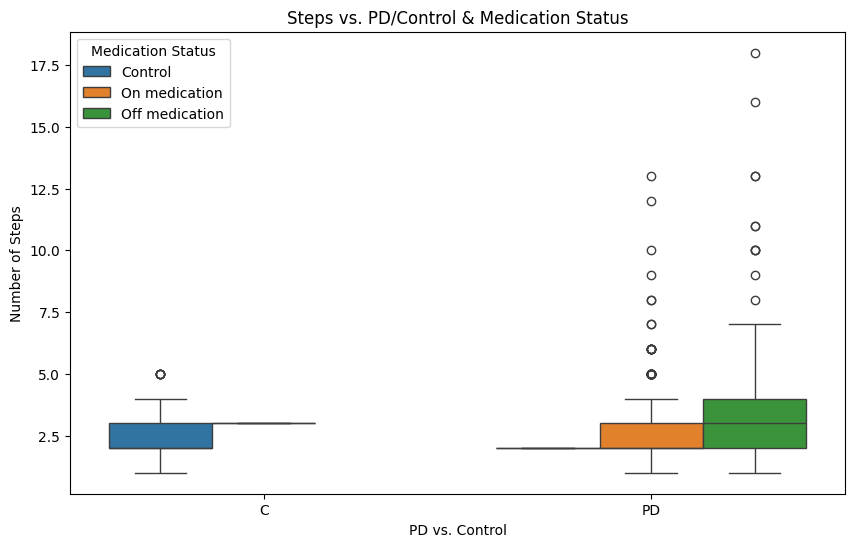

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="PD_or_C", y="number_of_turning_steps", hue="On_or_Off_medication", data=df)
plt.title("Steps vs. PD/Control & Medication Status")
plt.xlabel("PD vs. Control")
plt.ylabel("Number of Steps")
plt.legend(title="Medication Status")
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit two-way ANOVA model
model = ols("number_of_turning_steps ~ C(PD_or_C) * C(On_or_Off_medication)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Display results
print(anova_table)

                                         sum_sq      df           F  \
C(PD_or_C)                           229.758911     1.0  130.455776   
C(On_or_Off_medication)               66.302926     2.0   18.823208   
C(PD_or_C):C(On_or_Off_medication)     3.964620     2.0    1.125544   
Residual                            2999.326185  1703.0         NaN   

                                          PR(>F)  
C(PD_or_C)                          3.642526e-29  
C(On_or_Off_medication)             8.207872e-09  
C(PD_or_C):C(On_or_Off_medication)  3.247171e-01  
Residual                                     NaN  


<Figure size 800x600 with 0 Axes>

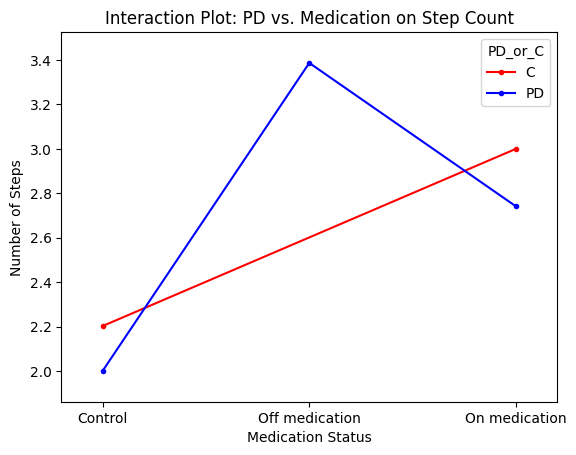

In [ ]:
from statsmodels.graphics.factorplots import interaction_plot

plt.figure(figsize=(8,6))
interaction_plot(df["On_or_Off_medication"], df["PD_or_C"], df["number_of_turning_steps"], colors=["red", "blue"])
plt.xlabel("Medication Status")
plt.ylabel("Number of Steps")
plt.title("Interaction Plot: PD vs. Medication on Step Count")
plt.show()

In [ ]:
top_angles = df["turning_angle"].value_counts()
print(top_angles)

turning_angle
90.0     924
180.0    554
135.0    222
225.0      6
270.0      1
360.0      1
Name: count, dtype: int64


In [ ]:
df = df[~df["turning_angle"].isin([225.0, 270.0, 360.0])]

In [ ]:
cnt = df["Turn ID"].count()
print(cnt)

1700


In [ ]:
df["filter"] = "Pt" + df["Participant ID number"].astype(str) + "_" + df["PD_or_C"] + "_n_" + df["Turn ID"].astype(str)

id_array = df["filter"].values

In [ ]:
id_array[0]

'Pt230_C_n_0'

In [ ]:
import os
import shutil

# Define paths
source_base = "/content/drive/My Drive/datata/Turning_coarsen_CSV"
destination_base = "/content/drive/My Drive/test"

# Create destination folder if it doesn't exist
os.makedirs(destination_base, exist_ok=True)

# Loop through IDs in id_array and copy matching files
missing_files = []
for folder_name in id_array:
    source_path = os.path.join(source_base, folder_name, "input_2D", "keypoints.csv")
    destination_path = os.path.join(destination_base, f"{folder_name}.csv")

    if os.path.exists(source_path):
        shutil.copy2(source_path, destination_path)  # Copy and rename
        print(f"Copied: {folder_name}")
    else:
        missing_files.append(folder_name)

# Print missing files, if any
if missing_files:
    print(f"\n⚠️ Missing files: {len(missing_files)}")
    for missing in missing_files[:10]:  # Show first 10 missing
        print(missing)


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, clear_output

# Define output directory for skeleton images
output_dir = "test1"
os.makedirs(output_dir, exist_ok=True)

### Load the CSV file directly ###
csv_file = 'Pt204_C_n_350.csv'  # Update this with your actual CSV file

dimension = 2
number_of_joints = 17
keypoints_csv = np.loadtxt(csv_file, delimiter=',')
keypoints = keypoints_csv.reshape(-1, number_of_joints, dimension)  # Reshape for multiple frames

connections = [[0, 1], [1, 2], [2, 3], [0, 4], [4, 5],
               [5, 6], [0, 7], [7, 8], [8, 9], [9, 10],
               [8, 11], [11, 12], [12, 13], [8, 14], [14, 15], [15, 16]]

LR = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=bool)

lcolor = (255, 0, 0)  # Blue (Left side)
rcolor = (0, 0, 255)  # Red (Right side)
base_thickness = 1

for idx in range(keypoints.shape[0]):  # Loop over all frames
    kps = keypoints[idx]
    max_dim = round(np.max(kps) * 1.3)
    img = np.zeros((max_dim, max_dim, 3), dtype='uint8')

    for j, c in enumerate(connections):
        start = tuple(map(int, kps[c[0]]))
        end = tuple(map(int, kps[c[1]]))

        thickness = 2 if j == 8 else base_thickness  # Thicker torso

        cv2.line(img, start, end, lcolor if LR[j] else rcolor, thickness)
        cv2.circle(img, start, thickness=-1, color=(0, 255, 0), radius=2)
        cv2.circle(img, end, thickness=-1, color=(0, 255, 0), radius=2)

    # Save image
    frame_path = os.path.join(output_dir, f"frame_{idx:04d}.png")
    cv2.imwrite(frame_path, img)
    print(f"Saved {frame_path}")


In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import json

# Input and output paths
data_dir = "/content/drive/My Drive/test"  # Folder containing CSV files
output_dir = "/content/drive/My Drive/to_img"
metadata_dir = "output/metadata/"

# Ensure output directories exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)

# OpenPose connections
connections = [[0, 1], [1, 2], [2, 3], [0, 4], [4, 5], [5, 6], [0, 7],
               [7, 8], [8, 9], [9, 10], [8, 11], [11, 12], [12, 13],
               [8, 14], [14, 15], [15, 16]]
LR = np.array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0], dtype=bool)

# Function to generate skeleton images
def generate_skeleton_image(kps, save_path):
    max_dim = round(np.max(kps) * 1.3)
    img = np.zeros((max_dim, max_dim, 3), dtype='uint8')
    lcolor, rcolor = (255, 0, 0), (0, 0, 255)

    for j, c in enumerate(connections):
        start, end = map(tuple, kps[c])
        color = lcolor if LR[j] else rcolor
        thickness = 2 if j == 8 else 1
        cv2.line(img, start, end, color, thickness)
        cv2.circle(img, start, 2, (0, 255, 0), -1)
        cv2.circle(img, end, 2, (0, 255, 0), -1)

    cv2.imwrite(save_path, img)

# Process all CSV files
csv_files = [f for f in os.listdir(data_dir) if f.endswith(".csv")]

for csv_file in tqdm(csv_files, desc="Processing CSV Files"):
    file_path = os.path.join(data_dir, csv_file)
    keypoints_csv = np.loadtxt(file_path, delimiter=',')
    keypoints = keypoints_csv.reshape(-1, 17, 2)

    trial_name = csv_file.replace(".csv", "")
    trial_dir = os.path.join(output_dir, trial_name)
    os.makedirs(trial_dir, exist_ok=True)

    metadata = {"filename": csv_file, "num_frames": keypoints.shape[0]}
    with open(os.path.join(metadata_dir, f"{trial_name}.json"), 'w') as f:
        json.dump(metadata, f)

    for idx, kps in enumerate(keypoints):
        save_path = os.path.join(trial_dir, f"frame_{idx:04d}.png")
        generate_skeleton_image(kps.astype(int), save_path)

print("Batch processing complete!")
